In [57]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math
import matplotlib.pyplot as plt

In [58]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol with an attacker, to demonstrate that the attacker can be detected.

1. Add Protocol Settings

In [59]:
backend = BasicSimulator()

# Protocol settings
N = 100                 # number of qubits Alice sends, 24 because BasicSimulator maximum qubits is 24. Ideally, this would be higher around 100 qubits
TEST_FRACTION = 0.5     # proportion of sifted key publicly checked
ATTACK_THRESHOLD = 0.1  # if error rate is above this, report attack

2. Create Quantum Bit Generator

In [60]:
def quantum_random_bits(number_of_bits, chunk_size=24): # Split the generation to 24 bits at a time, as that is the max BasicSimulator can handle at a time
    bits = []

    while len(bits) < number_of_bits:
        remaining = number_of_bits - len(bits)
        current_size = min(chunk_size, remaining)

        circuit = QuantumCircuit(current_size, current_size)
        circuit.h(range(current_size))
        circuit.measure(range(current_size), range(current_size))

        compiled = transpile(circuit, backend)
        job = backend.run(compiled, shots=1)
        result = job.result()
        bitstring = list(result.get_counts().keys())[0]

        bits.extend([int(bit) for bit in bitstring[::-1]]) # Qiskit displays classical bits right-to-left, so reverse it for q0, q1, q2, ... order.

    return bits

3. Alice, Bob, Eve (Attacker) interaction for one Qubit

In [61]:
def alice_prepare_eve_measure_bob_measure(alice_bit, alice_basis, eve_basis, bob_basis):

    # Intercept-resend attack:
    # 1. Alice prepares a qubit.
    # 2. Eve measures it using her randomly chosen basis.
    # 3. Eve sends Bob a new qubit matching her measured result and basis.
    # 4. Bob measures using his chosen basis.

    # Alice prepares the original qubit.
    eve_circuit = QuantumCircuit(1, 1)
    if alice_bit == 1:
        eve_circuit.x(0)
    if alice_basis == 1:
        eve_circuit.h(0)

    # Eve measures in her chosen basis.
    if eve_basis == 1:
        eve_circuit.h(0)
    eve_circuit.measure(0, 0)

    compiled = transpile(eve_circuit, backend)
    job = backend.run(compiled, shots=1)
    result = job.result()
    eve_result = int(list(result.get_counts().keys())[0])

    # Eve resends a newly prepared qubit based on what she measured.
    bob_circuit = QuantumCircuit(1, 1)
    if eve_result == 1:
        bob_circuit.x(0)
    if eve_basis == 1:
        bob_circuit.h(0)

    # Bob measures in his chosen basis.
    if bob_basis == 1:
        bob_circuit.h(0)
    bob_circuit.measure(0, 0)

    compiled = transpile(bob_circuit, backend)
    job = backend.run(compiled, shots=1)
    result = job.result()
    bob_result = int(list(result.get_counts().keys())[0])

    return eve_result, bob_result

4. Alice chooses secret bits and bases

In [62]:
# Alice randomly chooses data bits and bases using quantum randomness.
alice_bits = quantum_random_bits(N)
alice_bases = quantum_random_bits(N)

print("Alice bits: ", alice_bits)
print("Alice bases:", alice_bases)

Alice bits:  [0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
Alice bases: [0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0]


5. Eve chooses bases and prepares attack

In [63]:
# Eve randomly chooses bases and measures every qubit before Bob receives it.
eve_bases = quantum_random_bits(N)
eve_results = []

print("Eve bases:", eve_bases)

Eve bases: [1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1]


6. Bob chooses bases, Eve intercepts each Qubit

In [64]:
# Bob randomly chooses measurement bases using quantum randomness.
bob_bases = quantum_random_bits(N)
bob_results = []

for i in range(N):
    eve_result, bob_result = alice_prepare_eve_measure_bob_measure(
        alice_bits[i],
        alice_bases[i],
        eve_bases[i],
        bob_bases[i]
    )
    eve_results.append(eve_result)
    bob_results.append(bob_result)

print("Bob bases:  ", bob_bases)
print("Eve results:", eve_results)
print("Bob results:", bob_results)

Bob bases:   [0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0]
Eve results: [1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1]
Bob results: [0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1]


7. Public Comparison

In [65]:
matching_positions = []
for i in range(N):
    if alice_bases[i] == bob_bases[i]:
        matching_positions.append(i)

sifted_alice_key = [alice_bits[i] for i in matching_positions]
sifted_bob_key = [bob_results[i] for i in matching_positions]

print("Matching positions:", matching_positions)
print("Alice sifted key: ", sifted_alice_key)
print("Bob sifted key:   ", sifted_bob_key)

Matching positions: [0, 1, 4, 6, 8, 9, 10, 11, 14, 16, 19, 20, 23, 24, 25, 26, 28, 29, 30, 38, 39, 40, 45, 46, 48, 50, 52, 56, 60, 61, 62, 63, 64, 65, 70, 71, 74, 76, 81, 83, 84, 85, 89, 90, 93, 95, 96, 97, 98, 99]
Alice sifted key:  [0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0]
Bob sifted key:    [0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1]


8. Reveal test bits and get error rate

In [66]:
# They reveal part of the sifted key to estimate the error rate.
def choose_test_positions(key_length, test_size):
    chosen = []
    attempts = 0

    while len(chosen) < test_size and attempts < 10:
        candidate_bits = quantum_random_bits(key_length)
        for position, bit in enumerate(candidate_bits):
            if bit == 1 and position not in chosen:
                chosen.append(position)
                if len(chosen) == test_size:
                    break
        attempts += 1

    # If quantum choices did not fill enough positions, finish deterministically.
    # This is only to avoid an empty/unfinished test sample, not to generate randomness.
    for position in range(key_length):
        if len(chosen) == test_size:
            break
        if position not in chosen:
            chosen.append(position)

    return sorted(chosen)

if len(sifted_alice_key) == 0:
    test_size = 0
    test_positions = []
    errors = 0
    error_rate = 1
else:
    test_size = max(1, math.floor(len(sifted_alice_key) * TEST_FRACTION))
    test_positions = choose_test_positions(len(sifted_alice_key), test_size)

    errors = 0
    for position in test_positions:
        if sifted_alice_key[position] != sifted_bob_key[position]:
            errors += 1

    error_rate = errors / test_size

print("Random test positions:", test_positions)
print("Test size:", test_size)
print("Errors found:", errors)
print("Error rate:", error_rate)

Random test positions: [0, 1, 2, 5, 6, 7, 8, 14, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 28, 32, 34, 36, 38, 39, 42]
Test size: 25
Errors found: 3
Error rate: 0.12


9. Decide whether to use or reject key

In [67]:
# The unrevealed part would only be used if no attack is detected.
final_alice_key = []
final_bob_key = []

for position in range(len(sifted_alice_key)):
    if position not in test_positions:
        final_alice_key.append(sifted_alice_key[position])
        final_bob_key.append(sifted_bob_key[position])

attack_detected = error_rate > ATTACK_THRESHOLD
keys_match = final_alice_key == final_bob_key

summary = {
    "Scenario": "Intercept-resend attacker",
    "Qubits sent": N,
    "Matching bases": len(matching_positions),
    "Test bits revealed": test_size,
    "Errors in test bits": errors,
    "Error rate": round(error_rate, 3),
    "Detection threshold": ATTACK_THRESHOLD,
    "Attack detected?": attack_detected,
    "Final key length": len(final_alice_key),
    "Final keys match?": keys_match
}

print("BB84 WITH INTERCEPT-RESEND ATTACKER")
for label, value in summary.items():
    print(f"{label}: {value}")

if attack_detected:
    print("Decision: Attack detected, so Alice and Bob reject the key.")
else:
    print("Decision: No attack detected in the sample, so Alice and Bob may keep the unrevealed key.")

print("Final Alice key:", final_alice_key)
print("Final Bob key:  ", final_bob_key)

BB84 WITH INTERCEPT-RESEND ATTACKER
Scenario: Intercept-resend attacker
Qubits sent: 100
Matching bases: 50
Test bits revealed: 25
Errors in test bits: 3
Error rate: 0.12
Detection threshold: 0.1
Attack detected?: True
Final key length: 25
Final keys match?: False
Decision: Attack detected, so Alice and Bob reject the key.
Final Alice key: [1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0]
Final Bob key:   [1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1]


10. Display attacker circuit

Example: Alice uses X basis, Eve uses Z basis, Bob uses X basis


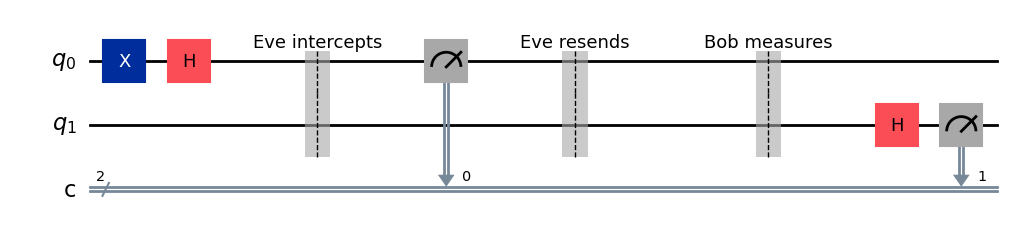

In [68]:
def attacker_example_circuit(alice_bit, alice_basis, eve_basis, bob_basis):
    qc = QuantumCircuit(2, 2)

    # q0 is Alice's original qubit.
    if alice_bit == 1:
        qc.x(0)
    if alice_basis == 1:
        qc.h(0)

    qc.barrier(label="Eve intercepts")

    # Eve measures Alice's qubit.
    if eve_basis == 1:
        qc.h(0)
    qc.measure(0, 0)

    qc.barrier(label="Eve resends")

    # q1 represents Eve's resent qubit.
    # This diagram shows the structure of the attack; the actual simulation above
    # uses Eve's measurement result to prepare the resent qubit.
    if eve_basis == 1:
        qc.h(1)

    qc.barrier(label="Bob measures")

    if bob_basis == 1:
        qc.h(1)
    qc.measure(1, 1)
    return qc

print("Example: Alice uses X basis, Eve uses Z basis, Bob uses X basis")
attacker_example_circuit(1, 1, 0, 1).draw("mpl")


11. Graph key statistics

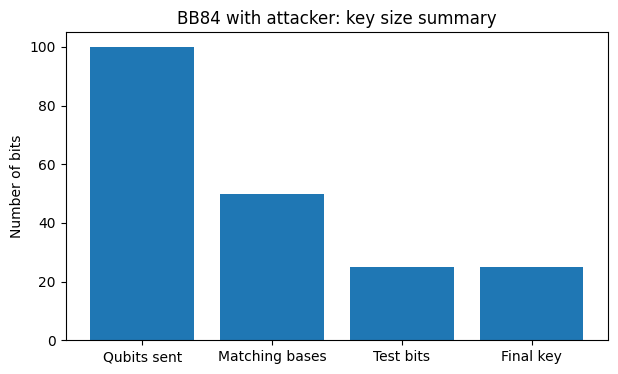

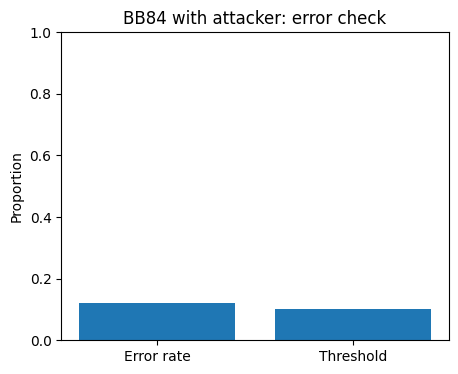

In [69]:
labels = ["Qubits sent", "Matching bases", "Test bits", "Final key"]
values = [N, len(matching_positions), test_size, len(final_alice_key)]

plt.figure(figsize=(7, 4))
plt.bar(labels, values)
plt.title("BB84 with attacker: key size summary")
plt.ylabel("Number of bits")
plt.show()

plt.figure(figsize=(5, 4))
plt.bar(["Error rate", "Threshold"], [error_rate, ATTACK_THRESHOLD])
plt.title("BB84 with attacker: error check")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.show()

12. Repeat attacker simulation multiple times to avoid randomness

Trials: 5
Average attacker error rate: 0.27550551647253296
Detection count: 5 out of 5
Average final key length: 25.2


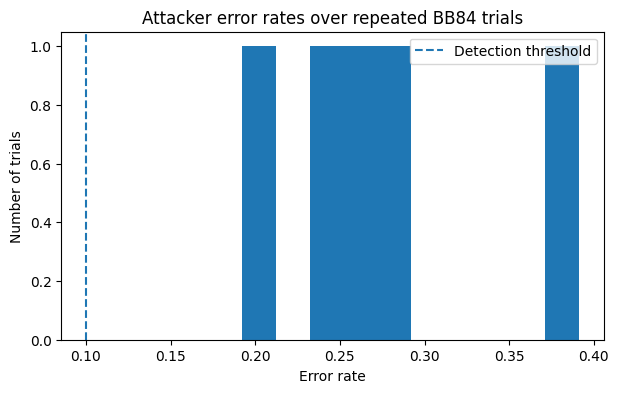

In [70]:
def simulate_attacker_fast(number_of_qubits, test_fraction, threshold):
    alice_bits = quantum_random_bits(number_of_qubits)
    alice_bases = quantum_random_bits(number_of_qubits)
    bob_bases = quantum_random_bits(number_of_qubits)
    eve_bases = quantum_random_bits(number_of_qubits)
    eve_wrong_random_bits = quantum_random_bits(number_of_qubits)

    sifted_alice = []
    sifted_bob = []

    for i in range(number_of_qubits):
        if alice_bases[i] == bob_bases[i]:
            sifted_alice.append(alice_bits[i])

            # If Eve used the correct basis, Bob receives the correct bit.
            # If Eve used the wrong basis, Bob's result is random.
            if eve_bases[i] == alice_bases[i]:
                sifted_bob.append(alice_bits[i])
            else:
                sifted_bob.append(eve_wrong_random_bits[i])

    if len(sifted_alice) == 0:
        return 1, True, 0

    test_size = max(1, math.floor(len(sifted_alice) * test_fraction))
    test_positions = choose_test_positions(len(sifted_alice), test_size)

    errors = 0
    for position in test_positions:
        if sifted_alice[position] != sifted_bob[position]:
            errors += 1

    error_rate = errors / test_size
    detected = error_rate > threshold
    final_key_length = len(sifted_alice) - test_size

    return error_rate, detected, final_key_length

TRIALS = 5
trial_error_rates = []
trial_detections = []
trial_key_lengths = []

for trial in range(TRIALS):
    trial_error_rate, trial_detected, trial_key_length = simulate_attacker_fast(N, TEST_FRACTION, ATTACK_THRESHOLD)
    trial_error_rates.append(trial_error_rate)
    trial_detections.append(trial_detected)
    trial_key_lengths.append(trial_key_length)

print("Trials:", TRIALS)
print("Average attacker error rate:", sum(trial_error_rates) / TRIALS)
print("Detection count:", sum(trial_detections), "out of", TRIALS)
print("Average final key length:", sum(trial_key_lengths) / TRIALS)

plt.figure(figsize=(7, 4))
plt.hist(trial_error_rates, bins=10)
plt.axvline(ATTACK_THRESHOLD, linestyle="--", label="Detection threshold")
plt.title("Attacker error rates over repeated BB84 trials")
plt.xlabel("Error rate")
plt.ylabel("Number of trials")
plt.legend()
plt.show()
